# 01 -- VQA consistency probe: Delta per pipeline on A-OKVQA

**Project 4 -- `04-vqa-aokvqa`**

This notebook summarises the quantitative results from the full evaluation run.
It loads `outputs/metrics.json`, renders the three-panel summary figure, and
prints the headline Delta per pipeline with its bootstrap 95% CI.

**Before running** this notebook, the full pipeline must have completed:

```
export P4_PROJECT_ROOT=$PWD/projects/04-vqa-aokvqa
uv run python projects/04-vqa-aokvqa/scripts/00_data.py
uv run python projects/04-vqa-aokvqa/scripts/10_run_pipelines.py
uv run python projects/04-vqa-aokvqa/scripts/20_probe.py
uv run python projects/04-vqa-aokvqa/scripts/30_eval.py
```

All cells below are idempotent once the outputs are present.

---

### Governance note

A-OKVQA images are never committed and do not appear in this notebook or its outputs.
Only aggregate numbers, figure panels, and pipeline identifiers are displayed.

---

### What we are measuring

Three zero-shot VQA pipelines (A, B, B7) are run on the A-OKVQA validation split.
The vision-ablation probe measures:

| Quantity | Meaning |
|---|---|
| self-rationale recoverability | P(ablated answer == original) with explanation present |
| consistency (no-expl baseline) | P(ablated answer == original) without explanation |
| Delta = with_expl - no_expl | Consistency gain attributable to the explanation |

Delta > 0 flags the self-rationale recoverability red flag; Delta near 0 means language
priors dominate; Delta < 0 is noise around zero (reported with CI, not over-interpreted).
See REPORT.md and ADR 004 for the full framing.

In [1]:
# ---------------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------------
"""VQA consistency probe notebook: Delta per pipeline on A-OKVQA."""
from __future__ import annotations

import contextlib
import json
import os
import pathlib
import sys
import warnings

import matplotlib.pyplot as plt

# Portfolio style (registers shared palette on import if available)
with contextlib.suppress(ImportError):
    import awake.viz.style  # noqa: F401

In [2]:
# ---------------------------------------------------------------------------
# Paths -- resolve project root via P4_PROJECT_ROOT env var
# ---------------------------------------------------------------------------
# Prefer an explicit env var (set by the caller or just recipe), then fall back
# to __file__ (undefined under nbconvert), then cwd candidates.
_project_root_env = os.environ.get("P4_PROJECT_ROOT", "")
_candidates: list[pathlib.Path] = []
if _project_root_env:
    _candidates.append(pathlib.Path(_project_root_env))
with contextlib.suppress(NameError):
    _candidates.append(pathlib.Path(__file__).resolve().parent.parent)
_cwd = pathlib.Path.cwd()
_candidates += [
    _cwd,
    _cwd.parent,
    _cwd / "projects" / "04-vqa-aokvqa",
]
PROJECT_ROOT = next(
    (
        d
        for d in _candidates
        if (d / "outputs" / "metrics.json").exists() or (d / "configs" / "data.yaml").exists()
    ),
    pathlib.Path(_project_root_env) if _project_root_env else _cwd,
)
METRICS_PATH = PROJECT_ROOT / "outputs" / "metrics.json"
HERO_PATH = PROJECT_ROOT / "assets" / "hero.png"

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"METRICS_PATH : {METRICS_PATH}")
print(f"HERO_PATH    : {HERO_PATH}")

PROJECT_ROOT : /home/manyee/interpretability-foundations/projects/04-vqa-aokvqa
METRICS_PATH : /home/manyee/interpretability-foundations/projects/04-vqa-aokvqa/outputs/metrics.json
HERO_PATH    : /home/manyee/interpretability-foundations/projects/04-vqa-aokvqa/assets/hero.png


In [3]:
# ---------------------------------------------------------------------------
# Guard: check that 30_eval.py has run
# ---------------------------------------------------------------------------
if not METRICS_PATH.exists():
    print(
        "ERROR: outputs/metrics.json not found at:\n"
        f"  {METRICS_PATH}\n\n"
        "Please run the full pipeline first:\n"
        "  export P4_PROJECT_ROOT=$PWD/projects/04-vqa-aokvqa\n"
        "  uv run python projects/04-vqa-aokvqa/scripts/00_data.py\n"
        "  uv run python projects/04-vqa-aokvqa/scripts/10_run_pipelines.py\n"
        "  uv run python projects/04-vqa-aokvqa/scripts/20_probe.py\n"
        "  uv run python projects/04-vqa-aokvqa/scripts/30_eval.py",
        file=sys.stderr,
    )
    raise FileNotFoundError(
        "outputs/metrics.json missing -- run 30_eval.py first. See message above."
    )

In [4]:
# ---------------------------------------------------------------------------
# Load metrics.json
# ---------------------------------------------------------------------------
with METRICS_PATH.open() as _fh:
    metrics_raw: dict = json.load(_fh)

# Expected top-level schema (see scripts/30_eval.py):
#   "split":           "validation"
#   "n":               <int>
#   "n_filtered":      <int>
#   "prompt_variant":  "main"
#   "model_revisions": {name: sha}
#   "b7_completed":    <bool>
#   "subsets":
#     "unfiltered":
#       "pipelines":
#         "A"/"B"/"B7":
#           "accuracy": float
#           "parse_rate": {"answer": float, "abl_expl": float, "abl_noexpl": float}
#           "expl_leak_rate": float
#           "consistency": {"with_expl": float, "no_expl": float,
#                           "delta": float, "delta_ci": [lo, hi]}
#       "divergence":
#         "A_vs_B"/"A_vs_B7"/"B_vs_B7":
#           "overall": float, "overall_ci": [lo, hi], "contingency": {...}
#     "filtered": same shape

unfiltered = metrics_raw.get("subsets", {}).get("unfiltered", {})
pipelines_data = unfiltered.get("pipelines", {})
divergence_data = unfiltered.get("divergence", {})

if not pipelines_data:
    warnings.warn(
        "metrics.json loaded but 'subsets.unfiltered.pipelines' is empty -- "
        "did 30_eval.py complete successfully?",
        stacklevel=1,
    )

In [5]:
# ---------------------------------------------------------------------------
# Print basic run info
# ---------------------------------------------------------------------------
print("=== Run summary ===")
print(f"  split          : {metrics_raw.get('split', '?')}")
print(f"  n (unfiltered) : {metrics_raw.get('n', '?')}")
print(f"  n (filtered)   : {metrics_raw.get('n_filtered', '?')}")
print(f"  prompt_variant : {metrics_raw.get('prompt_variant', '?')}")
print(f"  b7_completed   : {metrics_raw.get('b7_completed', '?')}")
revs = metrics_raw.get("model_revisions", {})
if revs:
    print("  model_revisions:")
    for k, v in revs.items():
        print(f"    {k}: {v}")

=== Run summary ===
  split          : validation
  n (unfiltered) : 1145
  n (filtered)   : 340
  prompt_variant : main
  b7_completed   : True
  model_revisions:
    blip2: 59a1ef6c1e5117b3f65523d1c6066825bcf315e3
    qwen_lm: a09a35458c702b33eeacc393d103063234e8bc28
    qwen_vl_3b: 66285546d2b821cf421d4f5eb2576359d3770cd3
    qwen_vl_7b: cc594898137f460bfe9f0759e9844b3ce807cfb5


## 1. Three-panel summary figure

The hero figure (`assets/hero.png`, generated by `scripts/30_eval.py`) shows three panels:

- **Panel 1 -- Delta per pipeline** (with 0 reference line). A bar above zero means
  the explanation helps the model recover its original answer when vision is ablated --
  the self-rationale recoverability red flag.
- **Panel 2 -- Accuracy** per pipeline on the original (non-ablated) answers.
- **Panel 3 -- Parse rate** per pipeline (fraction of outputs that parsed to a choice).

Showing all three panels together ensures a stably-wrong or image-ignoring pipeline
cannot look good on Delta alone.

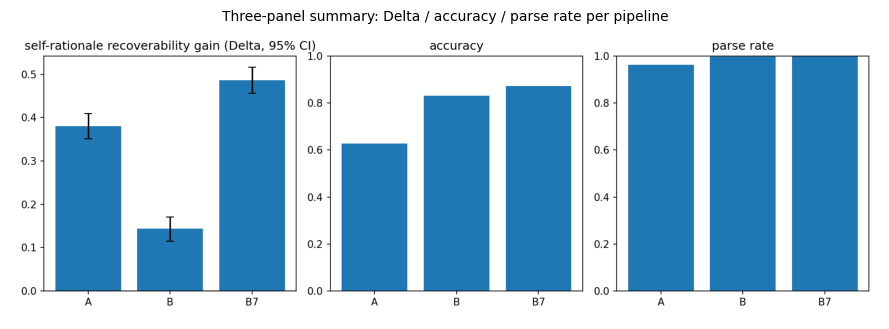

In [6]:
# ---------------------------------------------------------------------------
# Display pre-rendered hero figure
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))
if HERO_PATH.exists():
    try:
        img = plt.imread(str(HERO_PATH))
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(
            "Three-panel summary: Delta / accuracy / parse rate per pipeline",
            fontsize=10,
        )
    except Exception as exc:
        ax.text(
            0.5, 0.5,
            f"Could not load hero figure:\n{exc}\n\nRun 30_eval.py to generate it.",
            ha="center", va="center", transform=ax.transAxes,
            fontsize=9, color="firebrick",
        )
else:
    ax.text(
        0.5, 0.5,
        "assets/hero.png not found.\nRun 30_eval.py to generate it.",
        ha="center", va="center", transform=ax.transAxes,
        fontsize=9, color="firebrick",
    )
plt.tight_layout()
plt.show()

## 2. Headline Delta per pipeline with bootstrap 95% CIs

The table below shows, for each pipeline, the headline Delta and its paired-bootstrap
95% CI. A positive Delta means the explanation is the primary cue for answer recovery,
not the image. Delta near zero means language priors dominate. Delta < 0 is noise.

In [7]:
# ---------------------------------------------------------------------------
# Print headline Delta per pipeline
# ---------------------------------------------------------------------------
_PIPELINES = ("A", "B", "B7")

print("=== Headline Delta per pipeline (unfiltered, paired-bootstrap 95% CI) ===")
print(f"  {'Pipeline':<12}  {'with_expl':>9}  {'no_expl':>9}  {'Delta':>8}  {'CI [lo, hi]'}")
print("  " + "-" * 64)

for pname in _PIPELINES:
    pdata = pipelines_data.get(pname)
    if pdata is None:
        print(f"  {pname:<12}  (not in metrics.json)")
        continue
    cons = pdata.get("consistency", {})
    with_e = cons.get("with_expl", float("nan"))
    no_e = cons.get("no_expl", float("nan"))
    delta = cons.get("delta", float("nan"))
    ci = cons.get("delta_ci", [float("nan"), float("nan")])
    ci_lo = ci[0] if len(ci) > 0 else float("nan")
    ci_hi = ci[1] if len(ci) > 1 else float("nan")
    print(
        f"  {pname:<12}  {with_e:>9.4f}  {no_e:>9.4f}  {delta:>8.4f}"
        f"  [{ci_lo:+.4f}, {ci_hi:+.4f}]"
    )

print()

# Interpretation hint
print("Delta interpretation:")
print("  > 0  : explanation is the primary cue (self-rationale recoverability red flag)")
print("  ~0   : language priors dominate; image adds little on top of question alone")
print("  < 0  : noise around zero; reported with CI, not over-interpreted")

=== Headline Delta per pipeline (unfiltered, paired-bootstrap 95% CI) ===
  Pipeline      with_expl    no_expl     Delta  CI [lo, hi]
  ----------------------------------------------------------------
  A                0.9240     0.5441    0.3799  [+0.3511, +0.4087]
  B                0.6664     0.5223    0.1441  [+0.1153, +0.1703]
  B7               0.9860     0.4996    0.4865  [+0.4559, +0.5162]

Delta interpretation:
  > 0  : explanation is the primary cue (self-rationale recoverability red flag)
  ~0   : language priors dominate; image adds little on top of question alone
  < 0  : noise around zero; reported with CI, not over-interpreted


In [8]:
# ---------------------------------------------------------------------------
# Print accuracy and parse rate per pipeline
# ---------------------------------------------------------------------------
print("\n=== Accuracy and parse rate per pipeline (unfiltered) ===")
print(f"  {'Pipeline':<12}  {'Accuracy':>9}  {'PR(answer)':>10}  {'PR(abl_expl)':>12}  {'PR(abl_noexpl)':>14}  {'Leak rate':>9}")
print("  " + "-" * 80)

for pname in _PIPELINES:
    pdata = pipelines_data.get(pname)
    if pdata is None:
        print(f"  {pname:<12}  (not in metrics.json)")
        continue
    acc = pdata.get("accuracy", float("nan"))
    pr = pdata.get("parse_rate", {})
    leak = pdata.get("expl_leak_rate", float("nan"))
    pr_ans = pr.get("answer", float("nan"))
    pr_expl = pr.get("abl_expl", float("nan"))
    pr_noexpl = pr.get("abl_noexpl", float("nan"))
    print(
        f"  {pname:<12}  {acc:>9.4f}  {pr_ans:>10.4f}  {pr_expl:>12.4f}"
        f"  {pr_noexpl:>14.4f}  {leak:>9.4f}"
    )


=== Accuracy and parse rate per pipeline (unfiltered) ===
  Pipeline       Accuracy  PR(answer)  PR(abl_expl)  PR(abl_noexpl)  Leak rate
  --------------------------------------------------------------------------------
  A                0.6279      0.9633        0.9895          1.0000     0.8122
  B                0.8306      0.9974        1.0000          1.0000     0.2524
  B7               0.8734      1.0000        1.0000          1.0000     0.8664


In [9]:
# ---------------------------------------------------------------------------
# Print divergence summary
# ---------------------------------------------------------------------------
print("\n=== Inter-pipeline divergence (unfiltered, 95% CI) ===")
print(f"  {'Pair':<12}  {'Overall':>8}  {'CI [lo, hi]'}")
print("  " + "-" * 50)

for pair_key, div_data in divergence_data.items():
    overall = div_data.get("overall", float("nan"))
    oci = div_data.get("overall_ci", [float("nan"), float("nan")])
    oci_lo = oci[0] if len(oci) > 0 else float("nan")
    oci_hi = oci[1] if len(oci) > 1 else float("nan")
    print(f"  {pair_key:<12}  {overall:>8.4f}  [{oci_lo:.4f}, {oci_hi:.4f}]")


=== Inter-pipeline divergence (unfiltered, 95% CI) ===
  Pair           Overall  CI [lo, hi]
  --------------------------------------------------
  A_vs_B          0.3747  [0.3467, 0.4026]
  A_vs_B7         0.3642  [0.3362, 0.3930]
  B_vs_B7         0.1389  [0.1188, 0.1598]


## 3. Filtered subset (leakage-free)

Metrics on the filtered subset (items where no human rationale contains the gold
choice text verbatim) provide a cleaner signal by removing items where the gold
explanation already leaks the answer.

In [10]:
# ---------------------------------------------------------------------------
# Print filtered-subset Delta per pipeline
# ---------------------------------------------------------------------------
filtered = metrics_raw.get("subsets", {}).get("filtered", {})
filtered_pipelines = filtered.get("pipelines", {})

if filtered_pipelines:
    print("=== Headline Delta per pipeline (filtered / leakage-free, 95% CI) ===")
    print(f"  {'Pipeline':<12}  {'with_expl':>9}  {'no_expl':>9}  {'Delta':>8}  {'CI [lo, hi]'}")
    print("  " + "-" * 64)
    for pname in _PIPELINES:
        pdata = filtered_pipelines.get(pname)
        if pdata is None:
            print(f"  {pname:<12}  (not in metrics.json)")
            continue
        cons = pdata.get("consistency", {})
        with_e = cons.get("with_expl", float("nan"))
        no_e = cons.get("no_expl", float("nan"))
        delta = cons.get("delta", float("nan"))
        ci = cons.get("delta_ci", [float("nan"), float("nan")])
        ci_lo = ci[0] if len(ci) > 0 else float("nan")
        ci_hi = ci[1] if len(ci) > 1 else float("nan")
        print(
            f"  {pname:<12}  {with_e:>9.4f}  {no_e:>9.4f}  {delta:>8.4f}"
            f"  [{ci_lo:+.4f}, {ci_hi:+.4f}]"
        )
else:
    print("No filtered subset data found in metrics.json.")

=== Headline Delta per pipeline (filtered / leakage-free, 95% CI) ===
  Pipeline      with_expl    no_expl     Delta  CI [lo, hi]
  ----------------------------------------------------------------
  A                0.9235     0.5618    0.3618  [+0.3088, +0.4176]
  B                0.6735     0.5147    0.1588  [+0.1118, +0.2088]
  B7               0.9853     0.5206    0.4647  [+0.4088, +0.5206]


## 4. Discussion

_The full written discussion is in `REPORT.md` section 6; this is a reading guide for the
tables and figure above._

**Reading Delta:** a positive Delta for Pipeline A (caption-then-LLM) indicates that the
LLM recovers its original answer primarily from its own explanation rather than from any
residual image information -- exactly the self-rationale recoverability red flag the probe
was designed to detect. A near-zero Delta for either pipeline suggests the question alone
drives the answer, regardless of visual or explanatory context.

**Reading divergence:** high A-vs-B divergence with similar accuracy across the two
pipelines suggests the pipelines are failing on different items and succeeding on
different items -- potentially complementary error modes. The correctness-conditioned
contingency in `metrics.json` makes this inspectable at the item level.

**B-vs-B7:** the B-vs-B7 divergence pair isolates the effect of model capacity within
the direct-VLM family, bounding how much of the A-vs-B divergence is a parameter-count
artifact.

### Key limitations to keep in mind

- The probe is one family, not a battery. Delta measures one specific failure mode.
- Pipeline A ablation (null caption string) and Pipeline B ablation (black tile) are
  the natural ablations for each architecture but are not strictly comparable.
- The A-vs-B comparison remains confounded by model family and modality stack regardless
  of the B7 size-match arm.
- Parse rate is reported per arm: a pathologically low parse rate inflates apparent
  consistency (fewer items to be inconsistent on).

See `REPORT.md section 7` (Limitations) for the full list.